In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [68]:
data = pd.read_csv('housing.csv')

In [69]:
data.shape

(20640, 10)

In [70]:
data.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [71]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [72]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [73]:
#drop nan
data = data.dropna()
data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [74]:
# convert str to number (onehot) -> df_encoded

In [75]:
data["ocean_proximity"].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [76]:
df_encoded = pd.get_dummies(data, columns=["ocean_proximity"], dtype= int)

In [77]:
df_encoded.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [78]:
df_encoded.isnull().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_<1H OCEAN     0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

In [79]:
df_encoded.shape

(20433, 14)

In [80]:
#split train and test

In [81]:
x = df_encoded.drop(columns=["median_house_value"]).values
y = df_encoded[["median_house_value"]].values

indices = np.arange(x.shape[0])
np.random.shuffle(indices)

split_inx = int(0.8*indices.shape[0])

train , test = indices[:split_inx], indices[split_inx:]
x_train , x_test = x[train], x[test]
y_train , y_test = y[train], y[test]

In [82]:
print(f"X_train shape: {x_train.shape}")
print(f"Y_train shape: {y_train.shape}")

X_train shape: (16346, 13)
Y_train shape: (16346, 1)


In [83]:
print(f"X_train shape: {x_test.shape}")
print(f"Y_train shape: {y_test.shape}")

X_train shape: (4087, 13)
Y_train shape: (4087, 1)


# start deeplearning with numpy


In [84]:
rng = np.random.default_rng(42)

## activation ReLU

In [85]:
def relu(relu_input)-> np.ndarray:
    return np.maximum(0, relu_input)

## He initialaze

In [86]:
def he_initialize(num_inputs,num_out)-> np.ndarray:
    std = np.sqrt(2 / num_inputs)
    return rng.normal(0,std,size=(num_inputs,num_out))

## MSE LOSS

In [87]:
def mse_loss(mse_loss_x ,mse_loss_y) ->np.ndarray:
    return np.mean(np.square(mse_loss_x - mse_loss_y))

## Batch Normalization

In [88]:
#تفاوت اصلیِ Batch Normalization در دیپ‌لرنینگ با نرمال‌سازی ساده، این است که ما اجازه می‌دهیم شبکه خودش تصمیم بگیرد آیا واقعاً می‌خواهد خروجی‌اش نرمال باشد یا نه! برای این کار دو پارامتر قابل یادگیری به اسم Gamma ($\gamma$) و Beta ($\beta$) اضافه می‌کنیم.

In [89]:
#استفاده از var به جای std: در فرمول اصلی Batch Norm که در مقالات علمی (مثل مقاله اورجینال Sergey Ioffe) آمده، معمولاً از واریانس (var) استفاده می‌شود. اگر از std استفاده کنی، در مرحله Backward (که می‌خواهی مشتق بگیری)، فرمول ریاضی کمی پیچیده‌تر می‌شود. اگر از var استفاده کنی، مشتق‌گیری تمیزتر است.

In [90]:
def batch_norm(batch_norm_input,gamma,beta,eps=1e-5)-> np.ndarray:
    mean = np.mean(batch_norm_input,axis=0)
    var = np.var(batch_norm_input,axis=0)
    x_hat = (batch_norm_input - mean) / np.sqrt(var + eps)
    return gamma * x_hat + beta

## data normalization


In [91]:
x_mean = np.mean(x_train , axis=0)
x_std = np.std(x_train , axis=0)
x_std[x_std == 0] = 1

x_train_scaled = (x_train - x_mean) / x_std
x_test_scaled = (x_test - x_mean) / x_std

y_mean = np.mean(y_train , axis=0)
y_std = np.std(y_train , axis=0)
y_std[y_std == 0] = 1

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std


## dropout

In [92]:
# تو خود تابع dropout  اومد مشکل  تغییر میانگین را حل کرد !!

In [93]:
def dropout(arr,p=0.5,training=True)-> np.ndarray:
    if not training or p == 0:
        return arr

    mask = (rng.random(arr.shape) > p).astype(int)
    return (arr * mask) / (1-p)

In [94]:
# بایاس مستقیماً با خودِ «ماتریس وزن» جمع نمی‌شود. ابتدا ضرب ماتریسی داده‌ها در وزن انجام می‌شود، سپس بایاس به حاصلِ آن ضرب اضافه می‌شود و در نهایت کل این مجموعه وارد تابع اکتیویشن (ReLU) می‌شود.
#ترتیب میشه ضرب وزن در ورودی لایه + بایاس میره تو اکتیویشن

In [95]:
class NeuralNetwork:
    def __init__(self,input_dim,output_dim,hidden_layers,training_data,testing_data):
        self.weight_list = []
        self.bias_list = []
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_layers = hidden_layers
        self.training_data = training_data
        self.testing_data = testing_data
        self.initialize_weights(he_initializer = True)

    def initialize_weights(self,he_initializer = True):

        if he_initializer:
            self.weight_list.append(he_initialize(self.input_dim,self.hidden_layers[0]))
            self.bias_list.append(np.zeros((1, self.hidden_layers[0])))




            for index in range(len(self.hidden_layers)-1):
                self.weight_list.append(he_initialize(self.hidden_layers[index],self.hidden_layers[index+1]))
                self.bias_list.append(np.zeros((1, self.hidden_layers[index+1])))

            self.weight_list.append(he_initialize(self.hidden_layers[-1],self.output_dim))
            self.bias_list.append(np.zeros((1,self.output_dim)))

        else:
            self.weight_list.append(rng.normal(0,1,size=(self.input_dim,self.hidden_layers[0])))
            self.bias_list.append(np.zeros((1, self.hidden_layers[0])))

            for index in range(len(self.hidden_layers)-1):
                self.weight_list.append(rng.normal(0,1,size=(self.hidden_layers[index],self.hidden_layers[index+1])))
                self.bias_list.append(np.zeros((1,self.hidden_layers[index+1])))
            self.weight_list.append(rng.normal(0,1,size=(self.hidden_layers[-1],self.output_dim)))
            self.bias_list.append(np.zeros((1,self.output_dim)))

    def forward(self,x):
        self.input_x = x
        self.z_list = []
        self.a_list = []

        current_input = x

        for index in range(len(self.weight_list)-1):
            z = current_input @ self.weight_list[index] + self.bias_list[index]
            self.z_list.append(z)

            a = relu(self.z_list[index])
            self.a_list.append(a)

            current_input = self.a_list[index]

        last_z = current_input @ self.weight_list[-1] + self.bias_list[-1]
        self.z_list.append(last_z)
        self.a_list.append(last_z)
        return self.a_list[-1]

    def back_propagation(self, y_target):
        dLoss_dA = [0] * len(self.weight_list)
        dLoss_dA[-1] = 2 * (self.a_list[-1] - y_target)

        dLoss_dZ = [0] * len(self.weight_list)
        self.dLoss_dw = [0] * len(self.weight_list)
        self.dLoss_db = [0] * len(self.weight_list)  # اضافه کردن لیست گرادیان بایاس‌ها به کلاس

        for l in reversed(range(len(self.weight_list))):
            if l == len(self.weight_list) - 1:  # برای این هست که لایه اخر اکتیویشن اعمال نمیشه !
                relu_derivative = 1
            else:
                relu_derivative = (self.z_list[l] > 0).astype(int)

            dLoss_dZ[l] = relu_derivative * dLoss_dA[l]
            self.dLoss_db[l] = np.sum(dLoss_dZ[l], axis=0, keepdims=True)  # گرادیان بایاس ها

            if l == 0:
                a_prev = self.input_x
            else:
                a_prev = self.a_list[l - 1]
            self.dLoss_dw[l] = a_prev.T @ dLoss_dZ[l]

            if l > 0:
                dLoss_dA[l - 1] = dLoss_dZ[l] @ self.weight_list[l].T



    def update_weights(self,lr=0.001):
        for l in reversed(range(len(self.weight_list))):
            self.weight_list[l] -= lr * self.dLoss_dw[l]
            self.bias_list[l] -= lr * self.dLoss_db[l]


    def train(self, epochs, batch_size, lr=0.001):
        size_x_train =  self.training_data[0].shape[0]
        batch_index_size = int(np.ceil(size_x_train / batch_size))
        test_loss_list = []
        train_loss_list = []

        for epoch in range(epochs):
            #shuffle
            shuffle_index = rng.permutation(size_x_train)
            x_train_shuffled = self.training_data[0][shuffle_index]
            y_train_shuffled =self.training_data[1][shuffle_index]

            epoch_loss = 0

            for batch_index in range(batch_index_size):
                index_start = batch_index * batch_size
                index_end = min(batch_index * batch_size + batch_size ,size_x_train)

                out = self.forward(x_train_shuffled[index_start:index_end])
                self.back_propagation(y_train_shuffled[index_start:index_end])
                self.update_weights(lr=lr)

                batch_loss = mse_loss(out,y_train_shuffled[index_start:index_end])
                epoch_loss += batch_loss

            #ما میانگین هر بچ را تو هر ایپاک می خوایم
            epoch_loss = epoch_loss / batch_index_size

            x_test_i, y_test_i = self.testing_data[0], self.testing_data[1]
            test_out = self.forward(x_test_i)
            test_loss = mse_loss(test_out,y_test_i)
            test_loss_list.append(test_loss)
            train_loss_list.append(epoch_loss)

            if epoch % 10 == 0:


                print(f"Epoch {epoch+1:03d}/{epochs} | Train MSE: {epoch_loss:.6f} | Test MSE: {test_loss:.6f}")


        plt.figure(figsize=(10,5))
        plt.plot(train_loss_list, label="Train Loss", color="blue")
        plt.plot(test_loss_list, label="Test Loss", color="red")
        plt.title('Training and Testing Loss Over Epochs', fontsize=14)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(fontsize=12)

        plt.show()






# run!!!

Epoch 001/200 | Train MSE: 0.576217 | Test MSE: 0.453858
Epoch 011/200 | Train MSE: 0.312525 | Test MSE: 0.341258
Epoch 021/200 | Train MSE: 0.283456 | Test MSE: 0.310456
Epoch 031/200 | Train MSE: 0.267947 | Test MSE: 0.294226
Epoch 041/200 | Train MSE: 0.264493 | Test MSE: 0.285956
Epoch 051/200 | Train MSE: 0.255183 | Test MSE: 0.281429
Epoch 061/200 | Train MSE: 0.247705 | Test MSE: 0.274060
Epoch 071/200 | Train MSE: 0.243103 | Test MSE: 0.267989
Epoch 081/200 | Train MSE: 0.239386 | Test MSE: 0.269526
Epoch 091/200 | Train MSE: 0.236978 | Test MSE: 0.262244
Epoch 101/200 | Train MSE: 0.234677 | Test MSE: 0.262081
Epoch 111/200 | Train MSE: 0.232372 | Test MSE: 0.261746
Epoch 121/200 | Train MSE: 0.229049 | Test MSE: 0.257196
Epoch 131/200 | Train MSE: 0.227638 | Test MSE: 0.262507
Epoch 141/200 | Train MSE: 0.225076 | Test MSE: 0.254691
Epoch 151/200 | Train MSE: 0.225941 | Test MSE: 0.258974
Epoch 161/200 | Train MSE: 0.222307 | Test MSE: 0.252274
Epoch 171/200 | Train MSE: 0.22

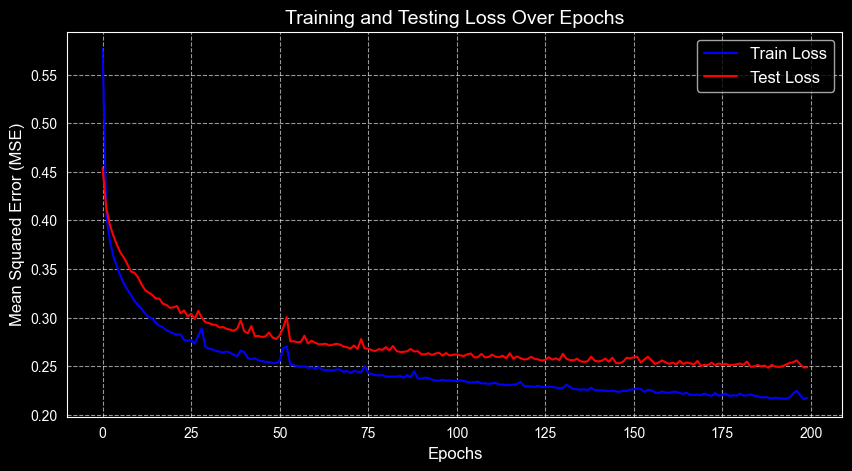

In [96]:
network_run = NeuralNetwork(
    input_dim=13,
    output_dim=1,
    hidden_layers=[64, 32],
    training_data=[x_train_scaled, y_train_scaled],
    testing_data=[x_test_scaled, y_test_scaled]
)

network_run.train(epochs=200, batch_size=32, lr=0.00005)

out_batch_size=100 --> Epoch 091/100 | Train MSE: 0.223233 | Test MSE: 0.234782

Epoch 001/200 | Train MSE: 0.575917 | Test MSE: 0.469008
Epoch 011/200 | Train MSE: 0.300090 | Test MSE: 0.322239
Epoch 021/200 | Train MSE: 0.270052 | Test MSE: 0.290615
Epoch 031/200 | Train MSE: 0.257158 | Test MSE: 0.277929
Epoch 041/200 | Train MSE: 0.249737 | Test MSE: 0.269115
Epoch 051/200 | Train MSE: 0.244312 | Test MSE: 0.264645
Epoch 061/200 | Train MSE: 0.239190 | Test MSE: 0.260275
Epoch 071/200 | Train MSE: 0.235596 | Test MSE: 0.259612
Epoch 081/200 | Train MSE: 0.231665 | Test MSE: 0.253328
Epoch 091/200 | Train MSE: 0.228851 | Test MSE: 0.251354
Epoch 101/200 | Train MSE: 0.226577 | Test MSE: 0.247889
Epoch 111/200 | Train MSE: 0.224275 | Test MSE: 0.246078
Epoch 121/200 | Train MSE: 0.222008 | Test MSE: 0.244213
Epoch 131/200 | Train MSE: 0.219690 | Test MSE: 0.242424
Epoch 141/200 | Train MSE: 0.217641 | Test MSE: 0.241523
Epoch 151/200 | Train MSE: 0.215745 | Test MSE: 0.239266
Epoch 161/200 | Train MSE: 0.213789 | Test MSE: 0.237037
Epoch 171/200 | Train MSE: 0.21

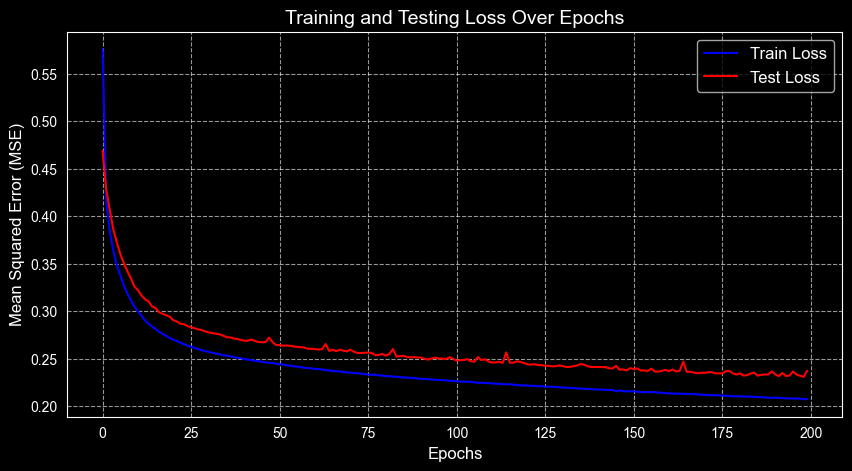

In [97]:
network_run = NeuralNetwork(
    input_dim=13,
    output_dim=1,
    hidden_layers=[32, 16],
    training_data=[x_train_scaled, y_train_scaled],
    testing_data=[x_test_scaled, y_test_scaled]
)

network_run.train(epochs=200, batch_size=32, lr=0.0001)